#### Experiment 1
- 1D
- Linear variation - electrode exponenets vary from -1 to -2
- 5 electrodes
- Aperiodic noise only
- Average by TS, PSD and SpecMod. Do not produce plots, save outputs
- Load in JSON output summaries and plot a single combined plot

In [1]:
# Imports for functionality 
from dissertation_simulations.time_series import sweep_electrodes_ts_2D
from dissertation_simulations.psd import sweep_electrodes_psd_2D
from dissertation_simulations.spec_mod import sweep_electrodes_specmod_2D
from dissertation_simulations.exponents import generate_spatial_exponent_matrix, generate_2D_exponent_matrix
from dissertation_simulations.plotting import plot_summary_boxplots

import numpy as np
import json

from scipy.stats import ttest_rel

In [2]:
exp_matrix = generate_2D_exponent_matrix(grid_shape=(1, 5), exp_range=(-2, -1), gradient_axis="cols")
exp_matrix

array([[-2.  , -1.75, -1.5 , -1.25, -1.  ]])

In [3]:
# Average the time series
exp_matrix = generate_2D_exponent_matrix(grid_shape=(1, 5), exp_range=(-2, -1), gradient_axis="cols")

electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_ts_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp1a_result1_ts = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1aresults1_ts_exp_matrix_cols_-1-2.json", "w") as f:
    json.dump(exp1a_result1_ts, f, indent=4)

In [4]:
# Average the PSD
exp_matrix = generate_2D_exponent_matrix(grid_shape=(1, 5), exp_range=(-2, -1), gradient_axis="cols")

electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp1a_result2_psd = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1aresults2_psd_exp_matrix_cols_-1-2.json", "w") as f:
    json.dump(exp1a_result2_psd, f, indent=4)

{'exponent': array([[-2.  , -1.75, -1.5 , -1.25, -1.  ]])}


In [5]:
# Average the SpecMod
exp_matrix = generate_2D_exponent_matrix(grid_shape=(1, 5), exp_range=(-2, -1), gradient_axis="cols")

electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp1a_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1aresults3_specmod_exp_matrix_cols_-1-2.json", "w") as f:
    json.dump(exp1a_result3_specmod, f, indent=4)

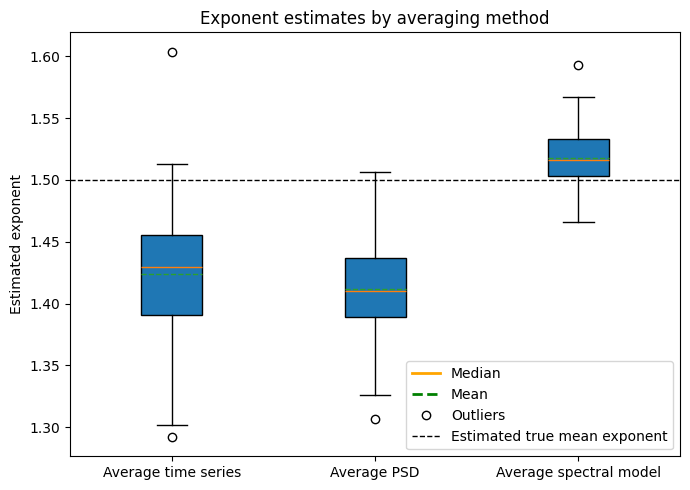

In [6]:
# Loading summaries and combining into a single plot

summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1aresults1_ts_exp_matrix_cols_-1-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1aresults2_psd_exp_matrix_cols_-1-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1aresults3_specmod_exp_matrix_cols_-1-2.json"
]

labels = [
    "Average time series",
    "Average PSD",
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\exp1a_combined_plot_1D_exp_matrix_cols_-1-2.png", dpi=300, bbox_inches="tight")

In [7]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1aresults1_ts_exp_matrix_cols_-1-2.json") as f:
    ts_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1aresults2_psd_exp_matrix_cols_-1-2.json") as f:
    psd_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1aresults3_specmod_exp_matrix_cols_-1-2.json") as f:
    spec_data = json.load(f)

ts = np.array(ts_data["all_distributions"][0])
psd = np.array(psd_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(ts, psd)
print(f"Time series vs PSD: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(ts, spec)
print(f"Time series vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd, spec)
print(f"PSD vs Spectral model: t = {t:.3f}, p = {p:.5f}")

Time series vs PSD: t = 1.700, p = 0.09226
Time series vs Spectral model: t = -17.147, p = 0.00000
PSD vs Spectral model: t = -24.653, p = 0.00000


#### Experiment 1b
- 1D
- Linear variation - electrode exponents vary from -1 to -1.5 - "middle out"
- 5 electrodes
- Aperiodic noise only
- Average by TS, PSD and SpecMod. Do not produce plots, save outputs
- Load in JSON output summaries and plot a single combined plot

In [8]:
# Define exponent matrix
exp_matrix = generate_spatial_exponent_matrix(grid_shape=(1, 5), exp_min=-1.5, exp_max=-1, pattern="middle")
exp_matrix

array([[-1.  , -1.25, -1.5 , -1.25, -1.  ]])

{'exponent': array([[-1.  , -1.25, -1.5 , -1.25, -1.  ]])}


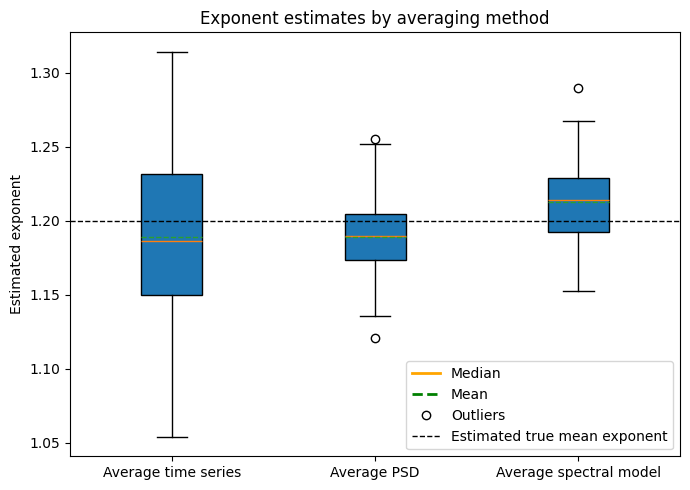

In [9]:
# Average the time series
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_ts_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp1b_result1_ts = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults1_ts_exp_matrix_radial_-1-1.5.json", "w") as f:
    json.dump(exp1b_result1_ts, f, indent=4)

# Average the PSD
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp1b_result2_psd = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults2_psd_exp_matrix_radial_-1-1.5.json", "w") as f:
    json.dump(exp1b_result2_psd, f, indent=4)

# Average the SpecMod
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp2_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults3_specmod_exp_matrix_radial_-1-1.5.json", "w") as f:
    json.dump(exp2_result3_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults1_ts_exp_matrix_radial_-1-1.5.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults2_psd_exp_matrix_radial_-1-1.5.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults3_specmod_exp_matrix_radial_-1-1.5.json"
]

labels = [
    "Average time series",
    "Average PSD",
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\exp1b_combined_plot_1D_exp_matrix_middle_-1-1.5.png", dpi=300, bbox_inches="tight")

In [10]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults1_ts_exp_matrix_radial_-1-1.5.json") as f:
    ts_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults2_psd_exp_matrix_radial_-1-1.5.json") as f:
    psd_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults3_specmod_exp_matrix_radial_-1-1.5.json") as f:
    spec_data = json.load(f)

ts = np.array(ts_data["all_distributions"][0])
psd = np.array(psd_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(ts, psd)
print(f"Time series vs PSD: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(ts, spec)
print(f"Time series vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd, spec)
print(f"PSD vs Spectral model: t = {t:.3f}, p = {p:.5f}")

Time series vs PSD: t = 0.068, p = 0.94623
Time series vs Spectral model: t = -3.566, p = 0.00056
PSD vs Spectral model: t = -6.597, p = 0.00000


#### Experiment 1c
- 1D
- Linear variation - electrode exponents vary from -1 to -1.5 radially - "middle in"
- 5 electrodes
- Aperiodic noise only
- Average by TS, PSD and SpecMod. Do not produce plots, save outputs
- Load in JSON output summaries and plot a single combined plot

In [11]:
# Define exponent matrix
exp_matrix = generate_spatial_exponent_matrix(grid_shape=(1, 5), exp_min=-1, exp_max=-1.5, pattern="middle")
exp_matrix

array([[-1.5 , -1.25, -1.  , -1.25, -1.5 ]])

{'exponent': array([[-1.5 , -1.25, -1.  , -1.25, -1.5 ]])}


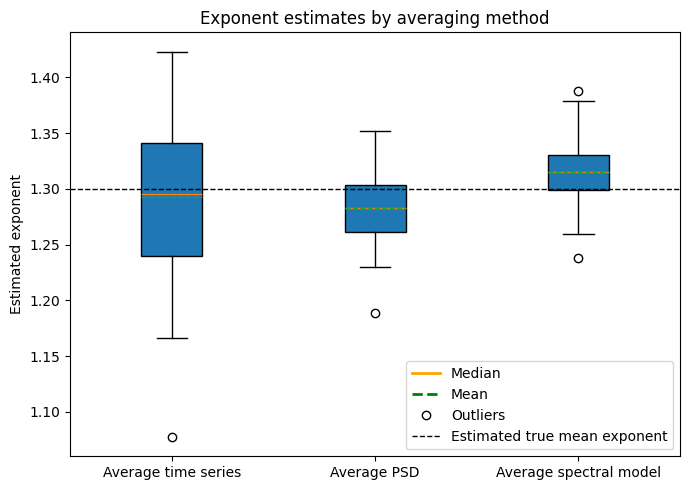

In [13]:
# Average the time series
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_ts_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp1c_result1_ts = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1cresults1_ts_exp_matrix_radial_-1-1.5.json", "w") as f:
    json.dump(exp1c_result1_ts, f, indent=4)

# Average the PSD
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp1c_result2_psd = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1cresults2_psd_exp_matrix_radial_-1-1.5.json", "w") as f:
    json.dump(exp1c_result2_psd, f, indent=4)

# Average the SpecMod
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=exp_matrix, 
                                                              n_repeats=100, plot=False, return_full=True)

exp1c_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1cresults3_specmod_exp_matrix_radial_-1-1.5.json", "w") as f:
    json.dump(exp1c_result3_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1cresults1_ts_exp_matrix_radial_-1-1.5.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1cresults2_psd_exp_matrix_radial_-1-1.5.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1cresults3_specmod_exp_matrix_radial_-1-1.5.json"
]

labels = [
    "Average time series",
    "Average PSD",
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\exp1c_combined_plot_1D_exp_matrix_middle_-1-1.5.png", dpi=300, bbox_inches="tight")

In [14]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1cresults1_ts_exp_matrix_radial_-1-1.5.json") as f:
    ts_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1cresults2_psd_exp_matrix_radial_-1-1.5.json") as f:
    psd_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1cresults3_specmod_exp_matrix_radial_-1-1.5.json") as f:
    spec_data = json.load(f)

ts = np.array(ts_data["all_distributions"][0])
psd = np.array(psd_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(ts, psd)
print(f"Time series vs PSD: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(ts, spec)
print(f"Time series vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd, spec)
print(f"PSD vs Spectral model: t = {t:.3f}, p = {p:.5f}")

Time series vs PSD: t = 1.355, p = 0.17858
Time series vs Spectral model: t = -3.350, p = 0.00115
PSD vs Spectral model: t = -8.158, p = 0.00000
